[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mbanuelos/grad_math_modeling/blob/main/Lectures/Module2_DataSimilarity/12_MLR.ipynb)

# MATH 232 - Math Models w/ Tech
## Multiple Linear Regression, Testing & Training Error
### Instructor: Prof. Mario Bañuelos 

In [1]:
# Import necessary packages
from IPython.display import HTML, Image
import numpy as np
from scipy import linalg as la
from scipy import sparse
import pandas as pd
# import plotting packages
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

# import sklearn and stats packages
from sklearn.preprocessing import scale
import sklearn.linear_model as skl_lm
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Outline

* [Multiple Linear Regression](#mlr)
  * [Simulated Data](#sim)
  * [Advertising Data](#advert)
* [Assessing Model Accuracy](#model-acc)
* [Further Reading](#reading)

# Multiple Linear Regression <a id='mlr'></a>


We continue with our linear regression journey, with more than one predictor,

$$
Y \approx \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_N X_n,
$$

where $\beta_0$ is still the intercept and $\beta_i$ ($i=1,2,\ldots,n$) are the coefficients associated to predictors $X_i$. 

We can also write this as 

$$
X \vec{\beta} = \vec{y}
$$


If $X$ is an $n \times p$ matrix, we solve this system by

$$
X^T X \vec{\beta} = X^T \vec{y}\\ \Rightarrow \vec{\beta} = (X^T X)^{-1} X^T \vec{y},
$$

which is the **least-squares estimate**.


### Warm-Up 1 (10-20 min).

Write a function called `simulate_mlr` (you can modify the `simulate_linear` code from the previous notebook) that outputs `[x1,x2], y` - which represents multiple linear simulated data. Then, run the following code to output the 3D scatterplot.

In [2]:
# simulate and plot data
X,Y = simulate_mlr(num=800,b0=3,b1=2,b2=5,random_seed=2)

# 3d figure
fig = go.Figure(data=[go.Scatter3d(
    x=X[0],
    y=X[1],
    z=Y,
    mode='markers'
)])

NameError: name 'simulate_mlr' is not defined

In [ ]:
fig.show()

## Advertising Data <a id='advert'></a>

Make sure that you have downloaded the <a href="https://www.dropbox.com/s/xk8n5b4f43n355n/Advertising.csv?dl=1"> Advertising data </a> before continuing.

In [2]:
advert = pd.read_csv('Advertising.csv', usecols=[1,2,3,4])
advert.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [3]:
advert

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [5]:
advert.TV

0      230.1
1       44.5
2       17.2
3      151.5
4      180.8
       ...  
195     38.2
196     94.2
197    177.0
198    283.6
199    232.1
Name: TV, Length: 200, dtype: float64

In [4]:
# Simple Linear Regression (Ordinary Least Squares)

# instantiate the model
regr = skl_lm.LinearRegression()

# rescale TV column by subtracting mean
X = scale(advert.TV, with_mean=True, with_std=False).reshape(-1,1)
y = advert.sales

# fit regression model with data and print estimated betas
regr.fit(X,y)
print(regr.intercept_)
print(regr.coef_)

14.0225
[0.04753664]


In [5]:
# Create grid coordinates for plotting
B0 = np.linspace(regr.intercept_-2, regr.intercept_+2, 50)
B1 = np.linspace(regr.coef_-0.02, regr.coef_+0.02, 50)
# create a grid based on B0 and B1
xx, yy = np.meshgrid(B0, B1, indexing='xy')
Z = np.zeros((B0.size,B1.size))

# Calculate Z-values (RSS) based on grid of coefficients
for (i,j),v in np.ndenumerate(Z):
    Z[i,j] =((y - (xx[i,j]+X.ravel()*yy[i,j]))**2).sum()/1000

# Minimized RSS
min_RSS = r'$\beta_0$, $\beta_1$ for minimized RSS'
min_rss = np.sum((regr.intercept_+regr.coef_*X - y.values.reshape(-1,1))**2)/1000
min_rss

2.1025305831313514

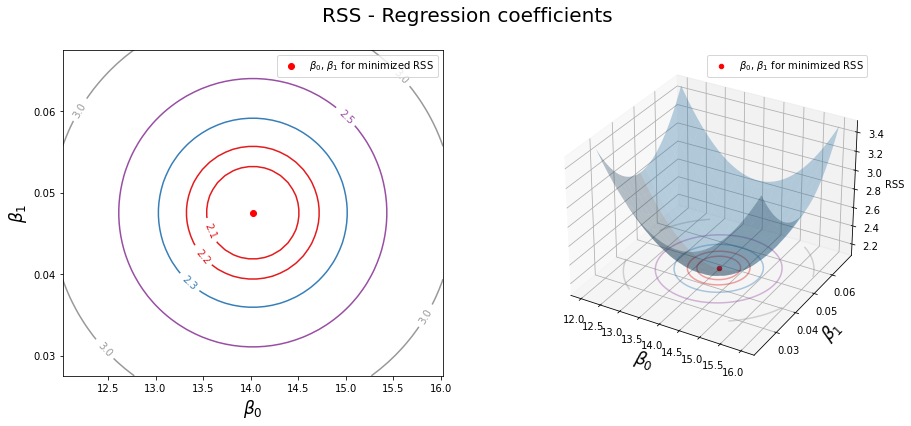

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import seaborn as sns

fig = plt.figure(figsize=(15,6))
fig.suptitle('RSS - Regression coefficients', fontsize=20)

ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection='3d')

# Left plot
CS = ax1.contour(xx, yy, Z, cmap=plt.cm.Set1, levels=[2.15, 2.2, 2.3, 2.5, 3])
ax1.scatter(regr.intercept_, regr.coef_[0], c='r', label=min_RSS)
ax1.clabel(CS, inline=True, fontsize=10, fmt='%1.1f')

# Right plot
ax2.plot_surface(xx, yy, Z, rstride=3, cstride=3, alpha=0.3)
ax2.contour(xx, yy, Z, zdir='z', offset=Z.min(), cmap=plt.cm.Set1,
            alpha=0.4, levels=[2.15, 2.2, 2.3, 2.5, 3])
ax2.scatter3D(regr.intercept_, regr.coef_[0], min_rss, c='r', label=min_RSS)
ax2.set_zlabel('RSS')
ax2.set_zlim(Z.min(),Z.max())
ax2.set_ylim(0.02,0.07)

# settings common to both plots
for ax in fig.axes:
    ax.set_xlabel(r'$\beta_0$', fontsize=17)
    ax.set_ylabel(r'$\beta_1$', fontsize=17)
    ax.set_yticks([0.03,0.04,0.05,0.06])
    ax.legend()

In [7]:
advert.sales

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

In [8]:
est = smf.ols('sales ~ radio', advert).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,9.3116,0.563,16.542,0.000,8.202,10.422
radio,0.2025,0.020,9.921,0.000,0.162,0.243


In [9]:
# RSS with regression coefficients
((advert.sales - (est.params[0] + est.params[1]*advert.radio))**2).sum()/1000

3.618479549025088

In [10]:
est2 = smf.ols('sales ~ radio + TV', advert).fit()
est2.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.9211,0.294,9.919,0.000,2.340,3.502
radio,0.1880,0.008,23.382,0.000,0.172,0.204
TV,0.0458,0.001,32.909,0.000,0.043,0.048


# Assessing Model Accuracy <a id='model-acc'></a>

In multiple regression settings, we can use the *residual sum of squares (RSS)* (generally known as the loss function $\mathcal{L}$), which is defined similarly as before

$$
\mathcal{L} = RSS = \sum^{n}_{i=1} \left( y_i - \hat{y_i}\right)^2 = \sum^{n}_{i=1} \left( y_i - \hat{f}(x_i)\right)^2 
$$

where $\hat{f}(x_i)$ is the prediction that $\hat{f}$ gives for the $i$th observation. 

**Goal:** Minimize the *RSS*! 

### Practice / Discussion 

Create the *best* multiple linear regression model.


## Further Reading <a id="reading"></a>


* <a href="https://github.com/JWarmenhoven/ISLR-python"> JWarmenhoven's Github </a>
* <a href="http://faculty.marshall.usc.edu/gareth-james/ISL/ISLR%20Seventh%20Printing.pdf"> Introduction to Statistical Learning
</a>